# Hardware Experiment Analysis
## Federated Fine-tuning with DP-SGD on Raspberry Pi
### Three-Person Personalization Study

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

BASE = '/home/clara/Research2.0/fyp_fl_smart_home/hardware_exp'

# Load all data
persons = {
    'Person A': {
        'nodp': pd.read_csv(f'{BASE}/person_A/finetune_results_nodp.csv'),
        'dp':   pd.read_csv(f'{BASE}/person_A/finetune_results_dp.csv'),
        'n_train': 10635,
        'color': '#2196F3'
    },
    'Person B': {
        'nodp': pd.read_csv(f'{BASE}/person_B/finetune_results_nodp.csv'),
        'dp':   pd.read_csv(f'{BASE}/person_B/finetune_results_dp.csv'),
        'n_train': 6515,
        'color': '#4CAF50'
    },
    'Person C': {
        'nodp': pd.read_csv(f'{BASE}/person_C/finetune_results_nodp.csv'),
        'dp':   pd.read_csv(f'{BASE}/person_C/finetune_results_dp.csv'),
        'n_train': 2198,
        'color': '#F44336'
    }
}

# Baseline (before fine-tuning)
baselines = {name: d['nodp']['acc_before'].iloc[0] for name, d in persons.items()}

print('Data loaded successfully!')
print()
for name, d in persons.items():
    print(f'{name} (n={d["n_train"]:,}):')
    print(f'  Before:       {baselines[name]*100:.2f}%')
    print(f'  After No DP:  {d["nodp"]["acc_after"].iloc[-1]*100:.2f}%')
    print(f'  After DP:     {d["dp"]["acc_after"].iloc[-1]*100:.2f}%')
    print(f'  DP drop:      {(d["nodp"]["acc_after"].iloc[-1] - d["dp"]["acc_after"].iloc[-1])*100:.2f}%')
    print()

Data loaded successfully!

Person A (n=10,635):
  Before:       39.68%
  After No DP:  98.23%
  After DP:     94.55%
  DP drop:      3.68%

Person B (n=6,515):
  Before:       48.56%
  After No DP:  100.00%
  After DP:     91.96%
  DP drop:      8.04%

Person C (n=2,198):
  Before:       31.27%
  After No DP:  99.09%
  After DP:     75.27%
  DP drop:      23.82%



## 1. Learning Curves — Accuracy per Round

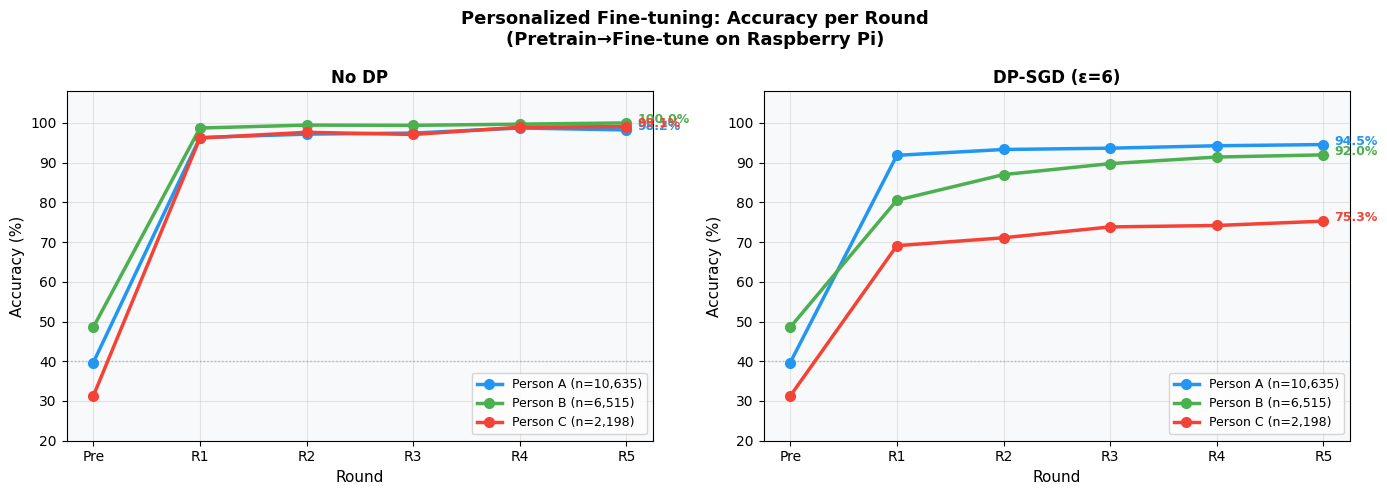

Saved: plot_learning_curves.png


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Personalized Fine-tuning: Accuracy per Round\n(Pretrain→Fine-tune on Raspberry Pi)',
             fontsize=13, fontweight='bold')

rounds = [0, 1, 2, 3, 4, 5]

for ax, condition, title in zip(axes, ['nodp', 'dp'], ['No DP', 'DP-SGD (ε=6)']):
    for name, d in persons.items():
        baseline = baselines[name]
        acc = [baseline] + d[condition]['acc_after'].tolist()
        ax.plot(rounds, [a*100 for a in acc],
                color=d['color'], marker='o', linewidth=2.5,
                markersize=7, label=f'{name} (n={d["n_train"]:,})')
        ax.annotate(f"{acc[-1]*100:.1f}%",
                    xy=(5, acc[-1]*100),
                    xytext=(5.1, acc[-1]*100),
                    fontsize=9, color=d['color'], fontweight='bold')

    ax.axhline(y=40, color='gray', linestyle=':', linewidth=1, alpha=0.5)
    ax.set_xlabel('Round', fontsize=11)
    ax.set_ylabel('Accuracy (%)', fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xticks(rounds)
    ax.set_xticklabels(['Pre', 'R1', 'R2', 'R3', 'R4', 'R5'])
    ax.set_ylim(20, 108)
    ax.legend(fontsize=9, loc='lower right')
    ax.grid(True, alpha=0.3)
    ax.set_facecolor('#f8f9fa')

plt.tight_layout()
plt.savefig(f'{BASE}/plot_learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: plot_learning_curves.png')

## 2. F1 Score Comparison

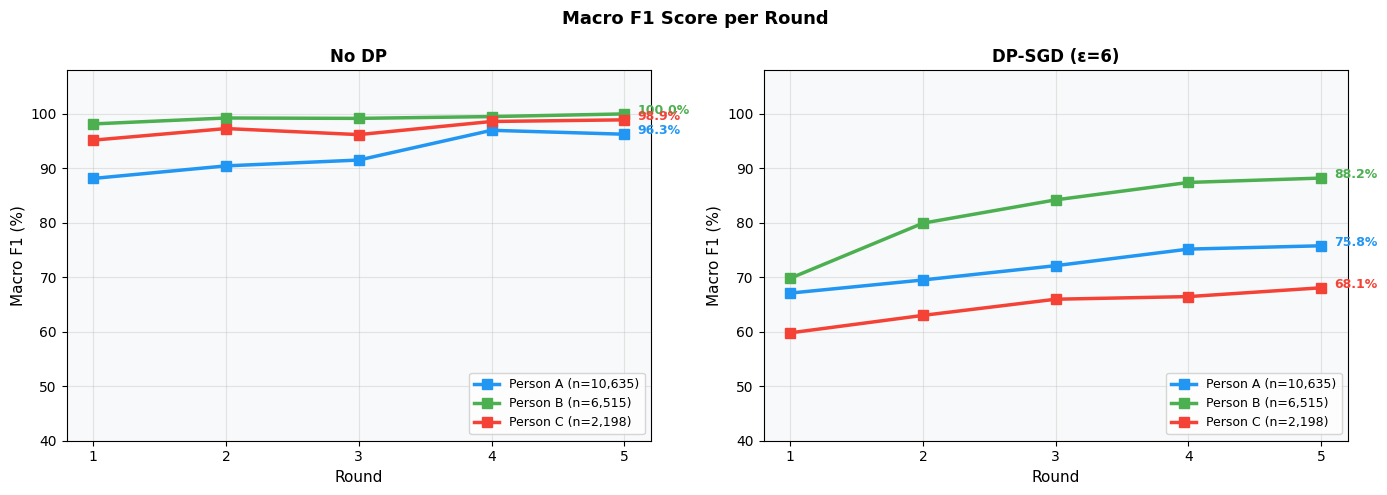

Saved: plot_f1_curves.png


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Macro F1 Score per Round', fontsize=13, fontweight='bold')

f1_rounds = [1, 2, 3, 4, 5]

for ax, condition, title in zip(axes, ['nodp', 'dp'], ['No DP', 'DP-SGD (ε=6)']):
    for name, d in persons.items():
        f1 = d[condition]['f1_after'].tolist()
        ax.plot(f1_rounds, [f*100 for f in f1],
                color=d['color'], marker='s', linewidth=2.5,
                markersize=7, label=f'{name} (n={d["n_train"]:,})')
        ax.annotate(f"{f1[-1]*100:.1f}%",
                    xy=(5, f1[-1]*100),
                    xytext=(5.1, f1[-1]*100),
                    fontsize=9, color=d['color'], fontweight='bold')

    ax.set_xlabel('Round', fontsize=11)
    ax.set_ylabel('Macro F1 (%)', fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xticks(f1_rounds)
    ax.set_ylim(40, 108)
    ax.legend(fontsize=9, loc='lower right')
    ax.grid(True, alpha=0.3)
    ax.set_facecolor('#f8f9fa')

plt.tight_layout()
plt.savefig(f'{BASE}/plot_f1_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: plot_f1_curves.png')

## 3. Privacy-Utility Tradeoff (Bar Chart)

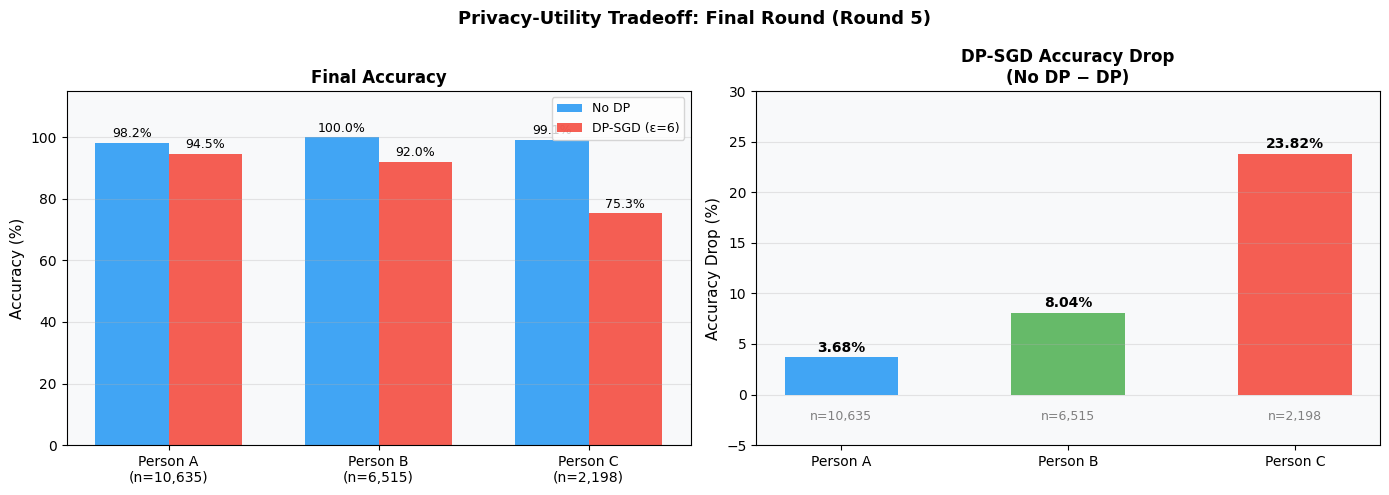

Saved: plot_privacy_utility.png


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Privacy-Utility Tradeoff: Final Round (Round 5)',
             fontsize=13, fontweight='bold')

person_names = list(persons.keys())
colors = [d['color'] for d in persons.values()]
x = np.arange(len(person_names))
width = 0.35

# Accuracy
ax1 = axes[0]
nodp_acc = [persons[p]['nodp']['acc_after'].iloc[-1]*100 for p in person_names]
dp_acc   = [persons[p]['dp']['acc_after'].iloc[-1]*100 for p in person_names]

b1 = ax1.bar(x - width/2, nodp_acc, width, label='No DP',
             color='#2196F3', alpha=0.85)
b2 = ax1.bar(x + width/2, dp_acc, width, label='DP-SGD (ε=6)',
             color='#F44336', alpha=0.85)
ax1.bar_label(b1, fmt='%.1f%%', padding=2, fontsize=9)
ax1.bar_label(b2, fmt='%.1f%%', padding=2, fontsize=9)
ax1.set_ylabel('Accuracy (%)', fontsize=11)
ax1.set_title('Final Accuracy', fontsize=12, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels([f'{p}\n(n={persons[p]["n_train"]:,})' for p in person_names])
ax1.set_ylim(0, 115)
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3, axis='y')
ax1.set_facecolor('#f8f9fa')

# DP accuracy drop
ax2 = axes[1]
dp_drop = [(persons[p]['nodp']['acc_after'].iloc[-1] -
            persons[p]['dp']['acc_after'].iloc[-1])*100 for p in person_names]

bars = ax2.bar(person_names, dp_drop, color=colors, alpha=0.85, width=0.5)
ax2.bar_label(bars, fmt='%.2f%%', padding=2, fontsize=10, fontweight='bold')

for i, (bar, n) in enumerate(zip(bars, [persons[p]['n_train'] for p in person_names])):
    ax2.text(bar.get_x() + bar.get_width()/2, -2.5,
             f'n={n:,}', ha='center', fontsize=9, color='gray')

ax2.set_ylabel('Accuracy Drop (%)', fontsize=11)
ax2.set_title('DP-SGD Accuracy Drop\n(No DP − DP)', fontsize=12, fontweight='bold')
ax2.set_ylim(-5, 30)
ax2.grid(True, alpha=0.3, axis='y')
ax2.set_facecolor('#f8f9fa')

plt.tight_layout()
plt.savefig(f'{BASE}/plot_privacy_utility.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: plot_privacy_utility.png')

## 4. Dataset Size vs DP Impact (Correlation Analysis)

Pearson r = -0.9545
p-value   = 0.1928
Interpretation: Strong negative correlation


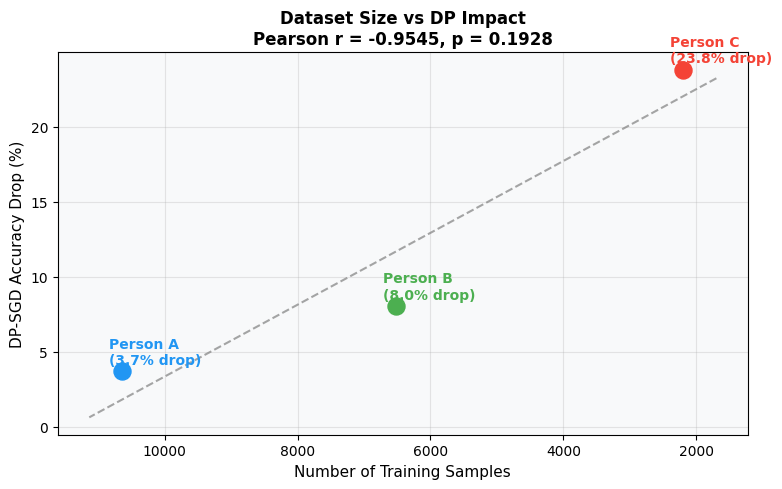

Saved: plot_correlation.png


In [15]:
n_samples = [persons[p]['n_train'] for p in person_names]
dp_drops  = [(persons[p]['nodp']['acc_after'].iloc[-1] -
              persons[p]['dp']['acc_after'].iloc[-1])*100 for p in person_names]

r, p_val = stats.pearsonr(n_samples, dp_drops)
print(f'Pearson r = {r:.4f}')
print(f'p-value   = {p_val:.4f}')
print(f'Interpretation: {"Strong" if abs(r) > 0.7 else "Moderate"} '
      f'{"negative" if r < 0 else "positive"} correlation')

fig, ax = plt.subplots(figsize=(8, 5))

for name, n, drop, color in zip(person_names, n_samples, dp_drops, colors):
    ax.scatter(n, drop, color=color, s=150, zorder=5)
    ax.annotate(f'{name}\n({drop:.1f}% drop)',
                xy=(n, drop), xytext=(n+200, drop+0.5),
                fontsize=10, color=color, fontweight='bold')

# Trend line
z = np.polyfit(n_samples, dp_drops, 1)
p_line = np.poly1d(z)
x_line = np.linspace(min(n_samples)-500, max(n_samples)+500, 100)
ax.plot(x_line, p_line(x_line), '--', color='gray', alpha=0.7, linewidth=1.5)

ax.set_xlabel('Number of Training Samples', fontsize=11)
ax.set_ylabel('DP-SGD Accuracy Drop (%)', fontsize=11)
ax.set_title(f'Dataset Size vs DP Impact\nPearson r = {r:.4f}, p = {p_val:.4f}',
             fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.set_facecolor('#f8f9fa')
ax.invert_xaxis()

plt.tight_layout()
plt.savefig(f'{BASE}/plot_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: plot_correlation.png')

## 5. Resource Analysis

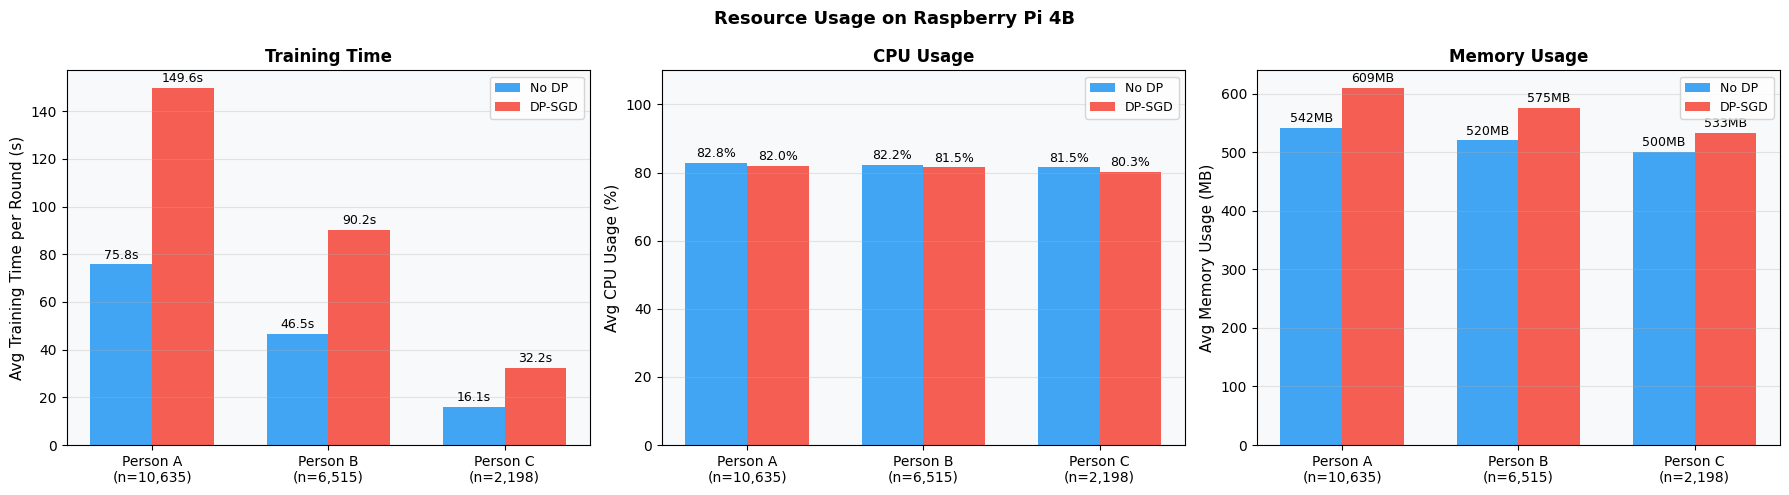

Saved: plot_resources.png


In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Resource Usage on Raspberry Pi 4B', fontsize=13, fontweight='bold')

x = np.arange(len(person_names))
width = 0.35

# Training time
ax1 = axes[0]
nodp_time = [persons[p]['nodp']['train_time_s'].mean() for p in person_names]
dp_time   = [persons[p]['dp']['train_time_s'].mean() for p in person_names]
b1 = ax1.bar(x - width/2, nodp_time, width, label='No DP', color='#2196F3', alpha=0.85)
b2 = ax1.bar(x + width/2, dp_time, width, label='DP-SGD', color='#F44336', alpha=0.85)
ax1.bar_label(b1, fmt='%.1fs', padding=2, fontsize=9)
ax1.bar_label(b2, fmt='%.1fs', padding=2, fontsize=9)
ax1.set_ylabel('Avg Training Time per Round (s)', fontsize=11)
ax1.set_title('Training Time', fontsize=12, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels([f'{p}\n(n={persons[p]["n_train"]:,})' for p in person_names])
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3, axis='y')
ax1.set_facecolor('#f8f9fa')

# CPU usage
ax2 = axes[1]
nodp_cpu = [persons[p]['nodp']['cpu_pct'].mean() for p in person_names]
dp_cpu   = [persons[p]['dp']['cpu_pct'].mean() for p in person_names]
b3 = ax2.bar(x - width/2, nodp_cpu, width, label='No DP', color='#2196F3', alpha=0.85)
b4 = ax2.bar(x + width/2, dp_cpu, width, label='DP-SGD', color='#F44336', alpha=0.85)
ax2.bar_label(b3, fmt='%.1f%%', padding=2, fontsize=9)
ax2.bar_label(b4, fmt='%.1f%%', padding=2, fontsize=9)
ax2.set_ylabel('Avg CPU Usage (%)', fontsize=11)
ax2.set_title('CPU Usage', fontsize=12, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels([f'{p}\n(n={persons[p]["n_train"]:,})' for p in person_names])
ax2.set_ylim(0, 110)
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3, axis='y')
ax2.set_facecolor('#f8f9fa')

# Memory usage
ax3 = axes[2]
nodp_mem = [persons[p]['nodp']['memory_mb'].mean() for p in person_names]
dp_mem   = [persons[p]['dp']['memory_mb'].mean() for p in person_names]
b5 = ax3.bar(x - width/2, nodp_mem, width, label='No DP', color='#2196F3', alpha=0.85)
b6 = ax3.bar(x + width/2, dp_mem, width, label='DP-SGD', color='#F44336', alpha=0.85)
ax3.bar_label(b5, fmt='%.0fMB', padding=2, fontsize=9)
ax3.bar_label(b6, fmt='%.0fMB', padding=2, fontsize=9)
ax3.set_ylabel('Avg Memory Usage (MB)', fontsize=11)
ax3.set_title('Memory Usage', fontsize=12, fontweight='bold')
ax3.set_xticks(x)
ax3.set_xticklabels([f'{p}\n(n={persons[p]["n_train"]:,})' for p in person_names])
ax3.legend(fontsize=9)
ax3.grid(True, alpha=0.3, axis='y')
ax3.set_facecolor('#f8f9fa')

plt.tight_layout()
plt.savefig(f'{BASE}/plot_resources.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: plot_resources.png')

## 6. Statistical Tests

In [17]:
print('\n' + '='*80)
print('SUMMARY TABLE')
print('='*80)
summary = pd.DataFrame({
    'Person': person_names,
    'N Train': [persons[p]['n_train'] for p in person_names],
    'Before (%)': [round(baselines[p]*100, 2) for p in person_names],
    'No DP Acc (%)': [round(persons[p]['nodp']['acc_after'].iloc[-1]*100, 2) for p in person_names],
    'DP Acc (%)': [round(persons[p]['dp']['acc_after'].iloc[-1]*100, 2) for p in person_names],
    'DP Drop (%)': [round(d, 2) for d in dp_drops],
    'No DP F1': [round(persons[p]['nodp']['f1_after'].iloc[-1], 4) for p in person_names],
    'DP F1': [round(persons[p]['dp']['f1_after'].iloc[-1], 4) for p in person_names],
    'No DP Time (s)': [round(persons[p]['nodp']['train_time_s'].mean(), 1) for p in person_names],
    'DP Time (s)': [round(persons[p]['dp']['train_time_s'].mean(), 1) for p in person_names],
    'Time Overhead (x)': [round(persons[p]['dp']['train_time_s'].mean() /
                                persons[p]['nodp']['train_time_s'].mean(), 2) for p in person_names],
    'No DP CPU (%)': [round(persons[p]['nodp']['cpu_pct'].mean(), 1) for p in person_names],
    'DP CPU (%)': [round(persons[p]['dp']['cpu_pct'].mean(), 1) for p in person_names],
    'No DP Mem (MB)': [round(persons[p]['nodp']['memory_mb'].mean(), 1) for p in person_names],
    'DP Mem (MB)': [round(persons[p]['dp']['memory_mb'].mean(), 1) for p in person_names],
    'Mem Overhead (MB)': [round(persons[p]['dp']['memory_mb'].mean() -
                               persons[p]['nodp']['memory_mb'].mean(), 1) for p in person_names],
})

# Print in two parts for readability
print('\n--- Accuracy & F1 ---')
print(summary[['Person', 'N Train', 'Before (%)', 'No DP Acc (%)',
               'DP Acc (%)', 'DP Drop (%)', 'No DP F1', 'DP F1']].to_string(index=False))

print('\n--- Resource Usage ---')
print(summary[['Person', 'No DP Time (s)', 'DP Time (s)', 'Time Overhead (x)',
               'No DP CPU (%)', 'DP CPU (%)',
               'No DP Mem (MB)', 'DP Mem (MB)', 'Mem Overhead (MB)']].to_string(index=False))

print('\n' + '='*80)


SUMMARY TABLE

--- Accuracy & F1 ---
  Person  N Train  Before (%)  No DP Acc (%)  DP Acc (%)  DP Drop (%)  No DP F1  DP F1
Person A    10635       39.68          98.23       94.55         3.68    0.9627 0.7579
Person B     6515       48.56         100.00       91.96         8.04    1.0000 0.8822
Person C     2198       31.27          99.09       75.27        23.82    0.9891 0.6808

--- Resource Usage ---
  Person  No DP Time (s)  DP Time (s)  Time Overhead (x)  No DP CPU (%)  DP CPU (%)  No DP Mem (MB)  DP Mem (MB)  Mem Overhead (MB)
Person A            75.8        149.6               1.97           82.8        82.0           541.6        609.2               67.6
Person B            46.5         90.2               1.94           82.2        81.5           519.9        575.5               55.6
Person C            16.1         32.2               2.00           81.5        80.3           499.8        533.3               33.5



## 7. Combined Summary Plot

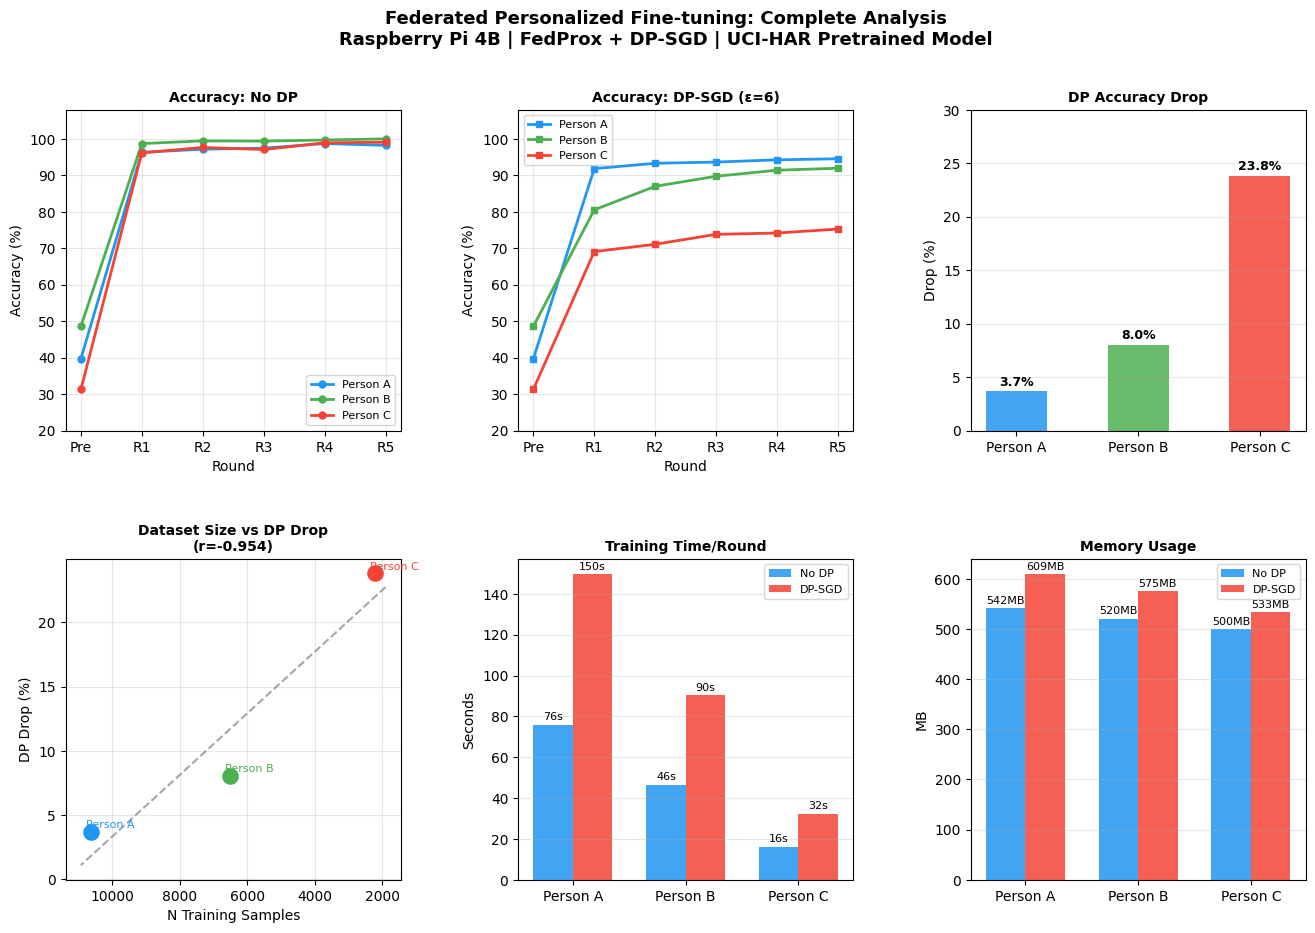

Saved: plot_complete_analysis.png


In [18]:
fig = plt.figure(figsize=(16, 10))
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

fig.suptitle('Federated Personalized Fine-tuning: Complete Analysis\n'
             'Raspberry Pi 4B | FedProx + DP-SGD | UCI-HAR Pretrained Model',
             fontsize=13, fontweight='bold')

rounds = [0, 1, 2, 3, 4, 5]

# 1. No DP learning curves
ax1 = fig.add_subplot(gs[0, 0])
for name, d in persons.items():
    acc = [baselines[name]] + d['nodp']['acc_after'].tolist()
    ax1.plot(rounds, [a*100 for a in acc], color=d['color'],
             marker='o', linewidth=2, markersize=5, label=name)
ax1.set_title('Accuracy: No DP', fontsize=10, fontweight='bold')
ax1.set_xlabel('Round'); ax1.set_ylabel('Accuracy (%)')
ax1.set_xticks(rounds); ax1.set_xticklabels(['Pre','R1','R2','R3','R4','R5'])
ax1.set_ylim(20, 108); ax1.legend(fontsize=8); ax1.grid(True, alpha=0.3)

# 2. DP learning curves
ax2 = fig.add_subplot(gs[0, 1])
for name, d in persons.items():
    acc = [baselines[name]] + d['dp']['acc_after'].tolist()
    ax2.plot(rounds, [a*100 for a in acc], color=d['color'],
             marker='s', linewidth=2, markersize=5, label=name)
ax2.set_title('Accuracy: DP-SGD (ε=6)', fontsize=10, fontweight='bold')
ax2.set_xlabel('Round'); ax2.set_ylabel('Accuracy (%)')
ax2.set_xticks(rounds); ax2.set_xticklabels(['Pre','R1','R2','R3','R4','R5'])
ax2.set_ylim(20, 108); ax2.legend(fontsize=8); ax2.grid(True, alpha=0.3)

# 3. DP drop bar
ax3 = fig.add_subplot(gs[0, 2])
dp_drops = [(persons[p]['nodp']['acc_after'].iloc[-1] -
             persons[p]['dp']['acc_after'].iloc[-1])*100 for p in person_names]
bars = ax3.bar(person_names, dp_drops, color=colors, alpha=0.85, width=0.5)
ax3.bar_label(bars, fmt='%.1f%%', padding=2, fontsize=9, fontweight='bold')
ax3.set_title('DP Accuracy Drop', fontsize=10, fontweight='bold')
ax3.set_ylabel('Drop (%)'); ax3.set_ylim(0, 30)
ax3.grid(True, alpha=0.3, axis='y')

# 4. Correlation
ax4 = fig.add_subplot(gs[1, 0])
n_samples = [persons[p]['n_train'] for p in person_names]
for name, n, drop, color in zip(person_names, n_samples, dp_drops, colors):
    ax4.scatter(n, drop, color=color, s=120, zorder=5)
    ax4.annotate(name, xy=(n, drop), xytext=(n+150, drop+0.3), fontsize=8, color=color)
z = np.polyfit(n_samples, dp_drops, 1)
x_line = np.linspace(min(n_samples)-300, max(n_samples)+300, 100)
ax4.plot(x_line, np.poly1d(z)(x_line), '--', color='gray', alpha=0.7)
r, _ = stats.pearsonr(n_samples, dp_drops)
ax4.set_title(f'Dataset Size vs DP Drop\n(r={r:.3f})', fontsize=10, fontweight='bold')
ax4.set_xlabel('N Training Samples'); ax4.set_ylabel('DP Drop (%)')
ax4.invert_xaxis(); ax4.grid(True, alpha=0.3)

# 5. Training time
ax5 = fig.add_subplot(gs[1, 1])
x = np.arange(len(person_names)); width = 0.35
nodp_time = [persons[p]['nodp']['train_time_s'].mean() for p in person_names]
dp_time   = [persons[p]['dp']['train_time_s'].mean() for p in person_names]
b1 = ax5.bar(x-width/2, nodp_time, width, label='No DP', color='#2196F3', alpha=0.85)
b2 = ax5.bar(x+width/2, dp_time, width, label='DP-SGD', color='#F44336', alpha=0.85)
ax5.bar_label(b1, fmt='%.0fs', padding=2, fontsize=8)
ax5.bar_label(b2, fmt='%.0fs', padding=2, fontsize=8)
ax5.set_title('Training Time/Round', fontsize=10, fontweight='bold')
ax5.set_ylabel('Seconds'); ax5.set_xticks(x)
ax5.set_xticklabels(person_names); ax5.legend(fontsize=8)
ax5.grid(True, alpha=0.3, axis='y')

# 6. Memory
ax6 = fig.add_subplot(gs[1, 2])
nodp_mem = [persons[p]['nodp']['memory_mb'].mean() for p in person_names]
dp_mem   = [persons[p]['dp']['memory_mb'].mean() for p in person_names]
b3 = ax6.bar(x-width/2, nodp_mem, width, label='No DP', color='#2196F3', alpha=0.85)
b4 = ax6.bar(x+width/2, dp_mem, width, label='DP-SGD', color='#F44336', alpha=0.85)
ax6.bar_label(b3, fmt='%.0fMB', padding=2, fontsize=8)
ax6.bar_label(b4, fmt='%.0fMB', padding=2, fontsize=8)
ax6.set_title('Memory Usage', fontsize=10, fontweight='bold')
ax6.set_ylabel('MB'); ax6.set_xticks(x)
ax6.set_xticklabels(person_names); ax6.legend(fontsize=8)
ax6.grid(True, alpha=0.3, axis='y')

plt.savefig(f'{BASE}/plot_complete_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: plot_complete_analysis.png')